In [1]:
"""
3D cones knee recon demo.
Changelog:
Reviewing and adding comments. Zhibo. Started: 03/26/2026. Ended: 03/26/2026.
"""
from Py_RawReadRecon_v1 import UIHRawRead

# This is for knee
root_path = '/home/zzhong/work/cones-recon/data/rawdata_0405/16807086960010-knee/'

rawdata_file = root_path + 'UID_7218582028655066955_gre_spiral__cones_3d_sf2_knee.raw'

raw_info = UIHRawRead.Run(rawdata_file, '3DCones')

*** protocol length: 96360
3DCones
Channel number is :12
Data estimating, please wait....
Reading data, please wait....
[14315, 1]
Saving data for k_920x14315x1_CHA12_Ech0_Set0_Rep0_Ave0_UD_0_0_0_0_0.npy
data size:  (12, 920, 14315, 1)


In [3]:
import numpy as np

ksp_file = root_path + '/UID_7218582028655066955_K/k_920x14315x1_CHA12_Ech0_Set0_Rep0_Ave0_UD_0_0_0_0_0.npy'
ksp = np.load(ksp_file)
ksp = np.expand_dims(ksp, axis=0)

# Print kspace data dimensionality:
# 1-Channel-ADC-PE-SPE
print(ksp.shape)

# Read ktraj and dens
ktraj_file = root_path + 'kacq_traj.txt'
with open(ktraj_file) as f:
    contents = f.readlines()

# ADC points without dummy samples
read_points = ksp.shape[2]-10+1;    

crds = np.zeros((read_points, 3, len(contents)))
for i in range(len(contents)):
    curLineStr = contents[i]
    curLineFloat = np.fromstring(curLineStr, dtype=float, sep=' ')
    crds[..., i] = np.reshape(curLineFloat, (-1, 3))

crds = np.expand_dims(crds, axis=0)
print(crds.shape)

# Read density compensation
dens_file = root_path + 'kacq_dens.txt'  
with open(dens_file) as f:
    contents = f.readlines()
    
dens = np.zeros((read_points, len(contents)))
for i in range(len(contents)):
    curLineStr = contents[i]
    curLineFloat = np.fromstring(curLineStr, dtype=float, sep=' ')
    dens[..., i] = curLineFloat
    
dens = np.expand_dims(dens, axis=0)  

(1, 12, 920, 14315, 1)
(1, 911, 3, 14315)


In [4]:
import numpy as np

coord = np.transpose(crds, [1, 3, 0, 2]) # num_ro, num_tr, num_slices, ndim
dcf = np.squeeze(np.transpose(dens, [1, 2, 0])) # num_ro, num_tr, num_slices
dcf = np.expand_dims(dcf, axis=2)

readout_length = 900;
coord = coord[:readout_length, :];
dcf = dcf[:readout_length, :];
ksp = ksp[:, :, 10:readout_length+10, :];

img_shape = [224, 224, 80]
num_phases = 1
ndim = coord.shape[-1]
num_echoes, num_coils, num_ro, num_tr, num_slices = ksp.shape[-5:]
# ksp = ksp.reshape([num_echoes, num_coils, num_slices*num_tr, num_ro])
# coord = coord_t.reshape([num_slices*num_tr, num_ro, 3])
# dcf = dcf.reshape([num_slices*num_tr, num_ro])

temp_x = coord[..., 0]
coord[..., 0] = temp_x * img_shape[0]
temp_y = coord[..., 1]
coord[..., 1] = temp_y * img_shape[1]
temp_z = coord[..., 2]
coord[..., 2] = temp_z * img_shape[2]

In [5]:
import time
import cupy as cp
import sigpy as sp

tic = time.perf_counter()
#start time count-----------------------
rss = 1
img = np.zeros([num_phases, 1, 1, num_echoes, 1, 1] + img_shape, dtype=np.complex64)

device = cp.cuda.Device(0)
with device:
    for e in range(num_echoes):
        for t in range(num_phases):
            # t_start = t * tr_per_frame
            # t_end = (t + 1) * tr_per_frame
            coord_t = cp.array(coord)
            dcf_t = cp.array(dcf)

            if rss:
                img_t = 0

            for c in range(num_coils):
                ksp_t = cp.array(ksp[e, c, :])
                ksp_t *= dcf_t
                img_tc = sp.nufft_adjoint(ksp_t, coord_t, img_shape)

                if rss:
                    img_t += cp.abs(img_tc)**2
                else:
                    sp.copyto(img[t, 0, 0, e, 0, c], img_tc)

            if rss:
                sp.copyto(img[t, 0, 0, e, 0, 0], img_t**0.5)

#stop time count-----------------------              
toc = time.perf_counter()
print(f"recon using: {toc - tic:0.4f} seconds") 

/home/zzhong/work/miniconda/install/envs/cones-recon/lib/python3.9/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


recon using: 6.5397 seconds


display images:  (224, 224, 80)
layout (row, col) is :  [8, 10]


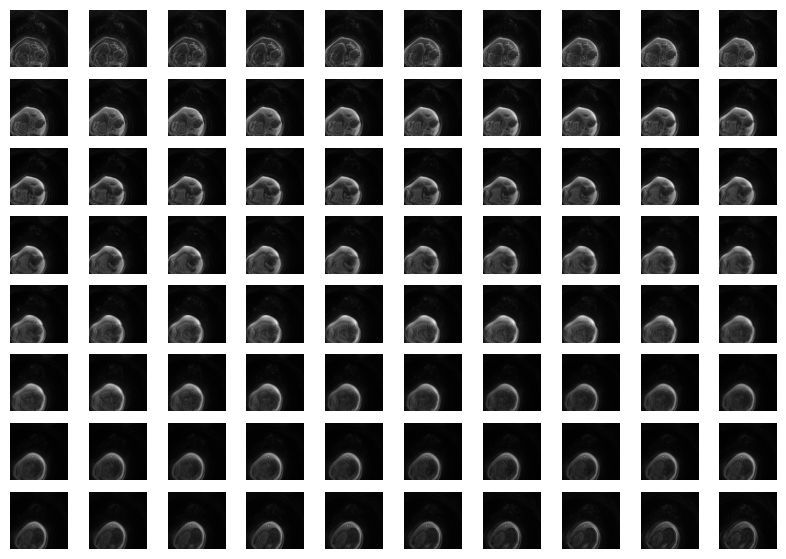

In [6]:
img2show = np.squeeze(img)#np.transpose(np.squeeze(img), [1, 2, 0])
from utils.imdisp import imdisp

imdisp(np.abs(img2show[:, :, :]))

display images:  (224, 224, 2)
layout (row, col) is :  [1, 2]


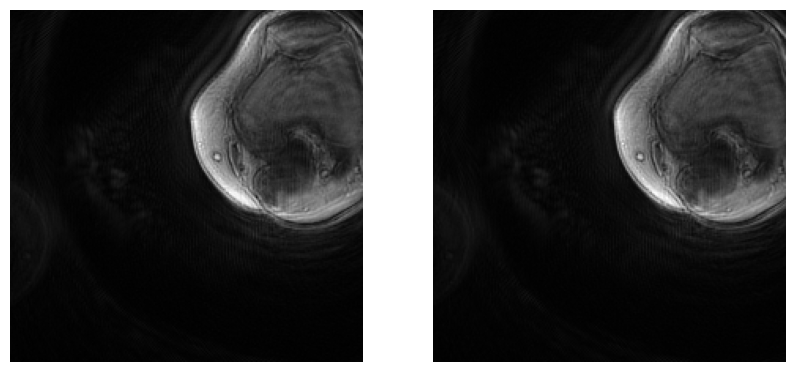

In [7]:
imdisp(np.transpose(np.abs(img2show[:, :, 32:34]), [1, 0, 2]))